# Streaming Video Subscriptions

Subscription records for MavenFlix, a fictitious video streaming platform. Dataset includes information for ~2,900 subscribers from September 2022 through September 2023. Each record represents an individual customer's subscription, including the subscription cost, created/canceled date, interval, and payment status.

**Recommended Analysis**
* How have Mavenflix subscriptions trended over time? 
* What percentage of customers have subscribed for 5 months or more? 
* What month has the highest subscriber retention, the lowest retention?

Import Packages and Dataset, as well as Instantiate Constant Variables

In [3]:
# Import Packages --------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

# Instantiate Constant Variables --------------
dataset_filename = "Subscription Cohort Analysis Data.csv";
dataset_dictionary_filename = "Subscription Cohort Analysis Data Dictionary.csv";

# Import Dataset ---------------------
df = pd.read_csv(dataset_filename);
df_dict = pd.read_csv(dataset_dictionary_filename);

In [4]:
print(df_dict.info());
df_dict.head()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Field        6 non-null      str  
 1   Description  6 non-null      str  
dtypes: str(2)
memory usage: 228.0 bytes
None


,Field,Description
0,customer_id,Unique customer identification number represen...
1,created_date,Date the customer subscription was created (MM...
2,canceled_date,Date the customer subscription was canceled (M...
3,subscription_cost,Price of the subscription in USD
4,subscription_interval,Measurement of time between billing occurrence...


In [5]:
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 3069 entries, 0 to 3068
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   customer_id            3069 non-null   int64
 1   created_date           3069 non-null   str  
 2   canceled_date          2004 non-null   str  
 3   subscription_cost      3069 non-null   int64
 4   subscription_interval  3069 non-null   str  
 5   was_subscription_paid  3069 non-null   str  
dtypes: int64(2), str(4)
memory usage: 144.0 KB
None


,customer_id,created_date,canceled_date,subscription_cost,subscription_interval,was_subscription_paid
0,154536156,2022-09-01,NaN,39,month,Yes
1,149713408,2022-09-01,2022-09-02,39,month,No
2,153756284,2022-09-01,2022-09-02,39,month,No
3,121253113,2022-09-01,2022-09-23,39,month,Yes
4,154467210,2022-09-01,2023-06-29,39,month,Yes


**1. How have Mavenflix subscriptions trended over time?**

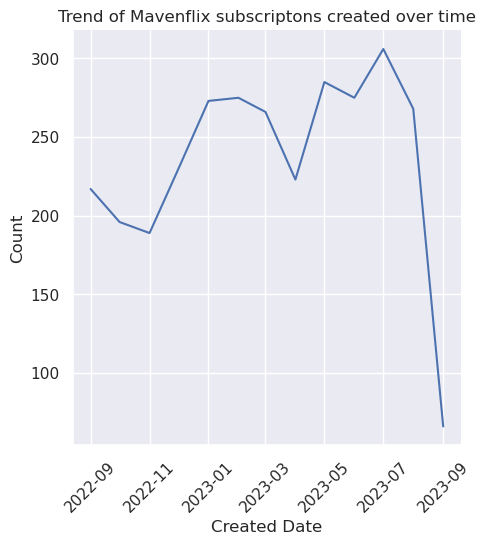

In [6]:
def trendOfSubscriptionsOverTime(data):
    dff = data.copy();
    dff = dff.sort_values(by=['created_date'], ascending=True);
    dff_agg = dff['created_date'].value_counts().sort_values();
    dataframe = pd.DataFrame({
        'Created Date': dff_agg.index.tolist(),
        'Count': dff_agg.values.tolist()
    });
    dataframe = dataframe.sort_values(by=['Created Date'], ascending=True).reset_index().drop(columns=['index']);
    dataframe['Created Date'] = pd.to_datetime(dataframe['Created Date']);
    monthly_df = dataframe.groupby(dataframe['Created Date'].dt.to_period('M')).sum(numeric_only=True).reset_index();
    monthly_df['Created Date'] = monthly_df['Created Date'].dt.to_timestamp();
    sns.relplot(data=monthly_df, x="Created Date", y="Count", kind="line").set(title="Trend of Mavenflix subscriptons created over time");
    plt.xticks(rotation=45);

trendOfSubscriptionsOverTime(df)

**2. What percentage of customers have subscribed for 5 months or more?**

,Subscribed for 5 months or more,Count,Percentage
0,True,1226,39.95
1,False,1843,60.05


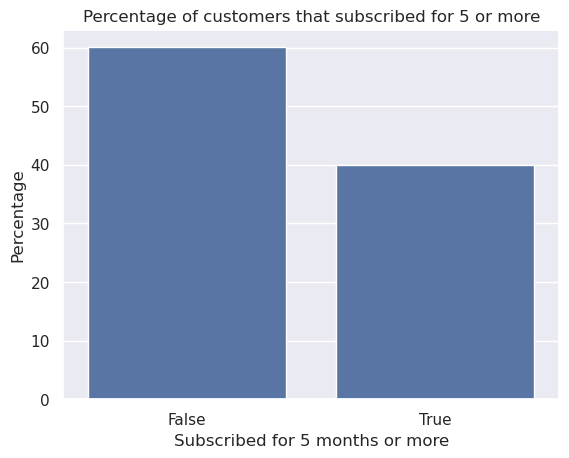

In [7]:
def customerSubscriptionDuration(data, monthLimit):
    dff = data.copy();
    dff = dff[['customer_id','created_date','canceled_date','was_subscription_paid']];
    effectiveDate = pd.Timestamp.now();
    dff['canceled_date'] = dff['canceled_date'].fillna(effectiveDate);
    for col in ['created_date','canceled_date']:
        dff[col] = pd.to_datetime(dff[col]);
    dff['duration'] = (dff['canceled_date'] - dff['created_date']).dt.days;
    for col in ['created_date','canceled_date']:
        dff[col] = dff[col].dt.strftime('%Y-%m-%d');
    daysLimit = monthLimit * 30;
    dff['above_threshold'] = dff['duration'] >= daysLimit;
    dff_agg = dff['above_threshold'].value_counts().sort_values();
    dataframe = pd.DataFrame({
        f"Subscribed for {monthLimit} months or more": dff_agg.index.tolist(),
        'Count': dff_agg.values.tolist()
    });
    dataframe["Percentage"] = np.round(np.multiply(dataframe["Count"] / dataframe['Count'].sum(), 100), 2);
    sns.barplot(data=dataframe, x=f"Subscribed for {monthLimit} months or more", y="Percentage").set(title=f"Percentage of customers that subscribed for {monthLimit} or more");
    return dataframe;

customerSubscriptionDuration(df, 5)

**3. What month has the highest subscriber retention, the lowest retention?**

,Created Date,Total Users,Active Users,Retention Rate
0,2022-09,217,162,74.65
1,2022-10,196,153,78.06
2,2022-11,189,144,76.19
3,2022-12,230,181,78.70
4,2023-01,273,215,78.75
5,2023-02,275,201,73.09
6,2023-03,266,201,75.56
7,2023-04,223,165,73.99
8,2023-05,285,222,77.89
9,2023-06,275,213,77.45


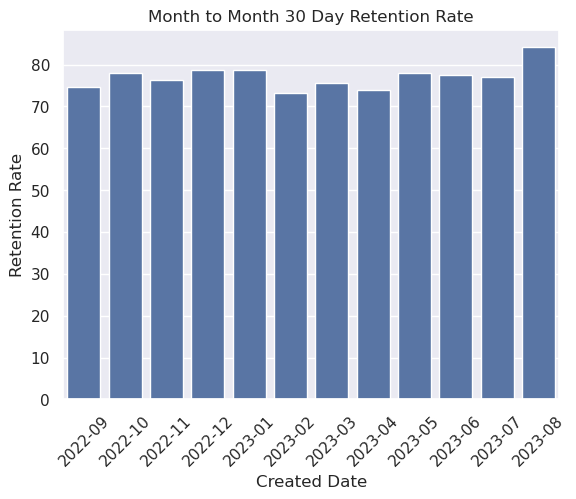

In [40]:
def subscriberRetention(data, dayLimit):
    dff = data.copy();
    for col in ['created_date','canceled_date']:
        dff[col] = pd.to_datetime(dff[col]);
    dff = dff.sort_values(by=['created_date'], ascending=True);
    
    dff['is_active'] = dff['canceled_date'].isna();
    
    effectiveDate = dff['created_date'].max();
    dff['canceled_date'] = dff['canceled_date'].fillna(effectiveDate);
    dff['duration'] = (dff['canceled_date'] - dff['created_date']).dt.days;
    dff[f"{dayLimit}_day_retained"] = dff['duration'] >= dayLimit;

    dff = dff[dff['created_date'] <= (effectiveDate - pd.Timedelta(days=dayLimit))];

    monthly_df = dff.groupby(dff['created_date'].dt.to_period('M')).agg(
        total_users=('customer_id','count'), 
        active_users=(f"{dayLimit}_day_retained",'sum')
    );
    
    monthly_df['retention_rate'] = np.round(np.multiply(np.divide(monthly_df['active_users'], monthly_df['total_users']), 100), 2);
    
    dataframe = pd.DataFrame({
        "Created Date": monthly_df.index.tolist(),
        "Total Users": monthly_df['total_users'].tolist(),
        "Active Users": monthly_df['active_users'].tolist(),
        "Retention Rate": monthly_df['retention_rate'].tolist()
    });

    sns.barplot(data=dataframe, x="Created Date", y="Retention Rate").set(title=f"Month to Month {dayLimit} Day Retention Rate");
    plt.xticks(rotation=45);

    return dataframe;

subscriberRetention(df, 30)

In [28]:
def subscriberRetention(data):
    dff = data.copy()
    for col in ['created_date','canceled_date']:
        dff[col] = pd.to_datetime(dff[col])
    
    # --- ADJUSTMENT START ---
    # 1. Use the latest date in your data as 'today'
    snapshot_date = dff['created_date'].max()
    
    # 2. Calculate days stayed (use snapshot_date if they haven't canceled)
    dff['days_stayed'] = (dff['canceled_date'].fillna(snapshot_date) - dff['created_date']).dt.days
    
    # 3. Define 'Retained' as surviving at least 30 days
    dff['is_retained_30d'] = dff['days_stayed'] >= 30
    # --- ADJUSTMENT END ---

    # Group by the month they joined
    monthly_df = dff.groupby(dff['created_date'].dt.to_period('M')).agg(
        total_users=('customer_id','count'), 
        # Sum our new boolean column instead of just checking for NaT
        active_users=('is_retained_30d','sum')
    )
    
    monthly_df['retention_rate'] = np.round((monthly_df['active_users'] / monthly_df['total_users']) * 100, 2)
    
    # Return as a clean DataFrame
    dataframe = pd.DataFrame({
        "Created Date": monthly_df.index.astype(str), # String for easier reading
        "30-Day Retention Rate": monthly_df['retention_rate'].tolist()
    })
    
    return dataframe

subscriberRetention(df)

,Created Date,30-Day Retention Rate
0,2022-09,74.65
1,2022-10,78.06
2,2022-11,76.19
3,2022-12,78.70
4,2023-01,78.75
5,2023-02,73.09
6,2023-03,75.56
7,2023-04,73.99
8,2023-05,77.89
9,2023-06,77.45
